In [1]:
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib
import sklearn
import skimage
import PIL
import joblib

print("Python        :", sys.version.split()[0])
print("OpenCV        :", cv2.__version__)
print("NumPy         :", np.__version__)
print("Pandas        :", pd.__version__)
print("Matplotlib    :", matplotlib.__version__)
print("scikit-learn  :", sklearn.__version__)
print("scikit-image  :", skimage.__version__)
print("Pillow        :", PIL.__version__)
print("joblib        :", joblib.__version__)

Python        : 3.11.8
OpenCV        : 4.9.0
NumPy         : 1.26.4
Pandas        : 2.2.1
Matplotlib    : 3.8.4
scikit-learn  : 1.5.1
scikit-image  : 0.26.0
Pillow        : 10.3.0
joblib        : 1.5.2


In [3]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent
DATASET_DIR = PROJECT_DIR / "Dataset" / "Dataset-Asli"

print("Project directory :", PROJECT_DIR)
print("Dataset directory :", DATASET_DIR)
print("Dataset ditemukan :", DATASET_DIR.exists())

Project directory : C:\Users\Asus\Klasifikasi_Sampah_KNN
Dataset directory : C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli
Dataset ditemukan : True


In [4]:
from pathlib import Path

kelas_info = {}

for kelas_dir in sorted(DATASET_DIR.iterdir()):
    if kelas_dir.is_dir():
        subkategori_info = {}
        total_kelas = 0

        for sub_dir in sorted(kelas_dir.iterdir()):
            if sub_dir.is_dir():
                jumlah_file = sum(1 for f in sub_dir.iterdir() if f.is_file())
                subkategori_info[sub_dir.name] = jumlah_file
                total_kelas += jumlah_file

        kelas_info[kelas_dir.name] = {
            "subkategori": subkategori_info,
            "total": total_kelas
        }

for kelas, info in kelas_info.items():
    print(f"\nKelas: {kelas}")
    for subkategori, jumlah in info["subkategori"].items():
        print(f"  - {subkategori}: {jumlah} file")
    print(f"Total {kelas}: {info['total']} file")

total_semua = sum(info["total"] for info in kelas_info.values())
print(f"\nTotal seluruh file: {total_semua}")


Kelas: Anorganik
  - Elektronik: 518 file
  - Kaca: 750 file
  - Kain: 450 file
  - Kardus: 580 file
  - Karet: 540 file
  - Kertas: 600 file
  - Logam: 598 file
  - Plastik: 717 file
  - Sepatu: 508 file
  - Styrofoam: 460 file
Total Anorganik: 5721 file

Kelas: Organik
  - Cangkang Telur: 661 file
  - Kayu: 535 file
  - Kotoran Hewan: 498 file
  - Sisa Buah: 801 file
  - Sisa makanan: 789 file
  - Sisa Teh Kopi: 597 file
  - Tumbuhan: 791 file
Total Organik: 4672 file

Total seluruh file: 10393


In [5]:
from PIL import Image
from collections import Counter

ekstensi_counter = Counter()
valid_files = []
invalid_files = []

for kelas_dir in sorted(DATASET_DIR.iterdir()):
    if kelas_dir.is_dir():
        for sub_dir in sorted(kelas_dir.iterdir()):
            if sub_dir.is_dir():
                for file_path in sub_dir.iterdir():
                    if file_path.is_file():
                        ekstensi_counter[file_path.suffix.lower()] += 1

                        try:
                            with Image.open(file_path) as img:
                                img.verify()
                            valid_files.append(file_path)
                        except Exception as e:
                            invalid_files.append((file_path, str(e)))

print("Jumlah seluruh file :", len(valid_files) + len(invalid_files))
print("Jumlah file valid   :", len(valid_files))
print("Jumlah file gagal   :", len(invalid_files))

print("\nDistribusi ekstensi:")
for ext, jumlah in sorted(ekstensi_counter.items()):
    print(f"{ext if ext else '[tanpa ekstensi]'}: {jumlah}")

if invalid_files:
    print("\nContoh file gagal:")
    for file_path, error in invalid_files[:20]:
        print(f"- {file_path} -> {error}")

Jumlah seluruh file : 10393
Jumlah file valid   : 10393
Jumlah file gagal   : 0

Distribusi ekstensi:
. in: 1
. schimmel - wegwerfen oder wegschneiden_: 1
.): 1
.125: 1
.5cm: 5
.6cm: 1
.ca: 1
.gif: 1
.jpeg: 3169
.jpg: 6556
.mooloolah: 1
.png: 634
.webp: 21


In [6]:
from collections import Counter

format_asli = Counter()
file_ekstensi_aneh = []

ekstensi_normal = {".jpg", ".jpeg", ".png", ".gif", ".webp"}

for file_path in valid_files:
    try:
        with Image.open(file_path) as img:
            format_asli[img.format] += 1

        if file_path.suffix.lower() not in ekstensi_normal:
            file_ekstensi_aneh.append(file_path)

    except Exception:
        pass

print("Format gambar sebenarnya:")
for fmt, jumlah in sorted(format_asli.items()):
    print(f"{fmt}: {jumlah}")

print("\nJumlah file dengan ekstensi tidak standar:", len(file_ekstensi_aneh))

if file_ekstensi_aneh:
    print("\nDaftar file dengan ekstensi tidak standar:")
    for f in file_ekstensi_aneh:
        print("-", f)

Format gambar sebenarnya:
GIF: 1
JPEG: 9725
PNG: 637
WEBP: 30

Jumlah file dengan ekstensi tidak standar: 12

Daftar file dengan ekstensi tidak standar:
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Karet\Ban Luar Tire Kenda Flame 24x2_125 K1008A 24 x 2.125
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Karet\MaxPower Rubber Inflatable Tubeless Rib Tread Wheelbarrow Tire 300 lbs_ Capacity 13 Dia. in
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Karet\Sasaki M-207BRM Meteor 18_5cm - COG-Cobalt Green _ 18.5cm
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Karet\Sasaki M-20A Gym Star 18_5cm - FFR-Fresh Red _ 18.5cm
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Karet\Sasaki M-20A Gym Star 18_5cm - FRO-Fresh Orange _ 18.5cm
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Karet\Sasaki M-20A Gym Star 18_5cm - RRK-Lilac _ 18.5cm
- C:\Users\Asus\Klasifikasi

In [7]:
import pandas as pd

data_distribusi = []

for kelas, info in kelas_info.items():
    for subkategori, jumlah in info["subkategori"].items():
        data_distribusi.append({
            "Kelas": kelas,
            "Subkategori": subkategori,
            "Jumlah": jumlah
        })

df_distribusi = pd.DataFrame(data_distribusi)

print(df_distribusi)

print("\nTotal per kelas:")
print(df_distribusi.groupby("Kelas")["Jumlah"].sum())

        Kelas     Subkategori  Jumlah
0   Anorganik      Elektronik     518
1   Anorganik            Kaca     750
2   Anorganik            Kain     450
3   Anorganik          Kardus     580
4   Anorganik           Karet     540
5   Anorganik          Kertas     600
6   Anorganik           Logam     598
7   Anorganik         Plastik     717
8   Anorganik          Sepatu     508
9   Anorganik       Styrofoam     460
10    Organik  Cangkang Telur     661
11    Organik            Kayu     535
12    Organik   Kotoran Hewan     498
13    Organik       Sisa Buah     801
14    Organik    Sisa makanan     789
15    Organik   Sisa Teh Kopi     597
16    Organik        Tumbuhan     791

Total per kelas:
Kelas
Anorganik    5721
Organik      4672
Name: Jumlah, dtype: int64


In [8]:
from pathlib import Path
from collections import defaultdict
import hashlib

file_kosong = []
file_aneh = []
hash_map = defaultdict(list)

ekstensi_normal = {".jpg", ".jpeg", ".png", ".gif", ".webp"}

for file_path in valid_files:
    # Cek file kosong
    if file_path.stat().st_size == 0:
        file_kosong.append(file_path)

    # Cek ekstensi tidak standar
    if file_path.suffix.lower() not in ekstensi_normal:
        file_aneh.append(file_path)

    # Cek duplikat berdasarkan isi file
    with open(file_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    hash_map[file_hash].append(file_path)

duplikat = {
    h: paths
    for h, paths in hash_map.items()
    if len(paths) > 1
}

print("Jumlah file kosong                :", len(file_kosong))
print("Jumlah file ekstensi tidak standar :", len(file_aneh))
print("Jumlah grup file duplikat          :", len(duplikat))

jumlah_file_duplikat = sum(len(paths) - 1 for paths in duplikat.values())
print("Jumlah file duplikat tambahan      :", jumlah_file_duplikat)

if duplikat:
    print("\nContoh grup duplikat:")
    for i, paths in enumerate(duplikat.values()):
        print(f"\nGrup {i+1}:")
        for p in paths:
            print("-", p)

        if i == 9:
            break

Jumlah file kosong                : 0
Jumlah file ekstensi tidak standar : 12
Jumlah grup file duplikat          : 275
Jumlah file duplikat tambahan      : 322

Contoh grup duplikat:

Grup 1:
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Elektronik\battery waste (18).jpg
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Elektronik\battery waste (19).jpg
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Elektronik\battery waste (20).jpg

Grup 2:
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Kaca\glass_176(1).jpg
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Plastik\plastic_461(1).jpg

Grup 3:
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Kardus\Image_1(1).png
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Kardus\Image_1.png

Grup 4:
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Asli\Anorganik\Kardus\Image_10(1).png
- C:\U

In [9]:
duplikat_beda_kelas = []
duplikat_beda_subkategori = []
duplikat_sama_subkategori = []

for paths in duplikat.values():
    info = []

    for p in paths:
        relatif = p.relative_to(DATASET_DIR)
        kelas = relatif.parts[0]
        subkategori = relatif.parts[1]

        info.append({
            "path": p,
            "kelas": kelas,
            "subkategori": subkategori
        })

    kelas_unik = set(x["kelas"] for x in info)
    subkategori_unik = set(
        (x["kelas"], x["subkategori"])
        for x in info
    )

    if len(kelas_unik) > 1:
        duplikat_beda_kelas.append(info)

    elif len(subkategori_unik) > 1:
        duplikat_beda_subkategori.append(info)

    else:
        duplikat_sama_subkategori.append(info)

print("Duplikat dalam subkategori yang sama :", len(duplikat_sama_subkategori))
print("Duplikat antar subkategori           :", len(duplikat_beda_subkategori))
print("Duplikat antar kelas utama           :", len(duplikat_beda_kelas))

if duplikat_beda_kelas:
    print("\nDuplikat antar kelas utama:")
    for i, grup in enumerate(duplikat_beda_kelas[:20], 1):
        print(f"\nGrup {i}")
        for item in grup:
            print(
                f"- {item['kelas']} | "
                f"{item['subkategori']} | "
                f"{item['path'].name}"
            )

Duplikat dalam subkategori yang sama : 273
Duplikat antar subkategori           : 2
Duplikat antar kelas utama           : 0


In [10]:
print("Duplikat antar subkategori:")

for i, grup in enumerate(duplikat_beda_subkategori, 1):
    print(f"\nGrup {i}")
    for item in grup:
        print(
            f"- Kelas       : {item['kelas']}\n"
            f"  Subkategori : {item['subkategori']}\n"
            f"  File        : {item['path'].name}"
        )

Duplikat antar subkategori:

Grup 1
- Kelas       : Anorganik
  Subkategori : Kaca
  File        : glass_176(1).jpg
- Kelas       : Anorganik
  Subkategori : Plastik
  File        : plastic_461(1).jpg

Grup 2
- Kelas       : Organik
  Subkategori : Kotoran Hewan
  File        : OIP - 2025-05-06T182212.183.jpeg
- Kelas       : Organik
  Subkategori : Kotoran Hewan
  File        : OIP - 2025-05-21T113240.811.jpeg
- Kelas       : Organik
  Subkategori : Sisa Teh Kopi
  File        : OIP - 2025-05-22T144929.212.jpeg


In [11]:
import shutil
from pathlib import Path

DATASET_BERSIH_DIR = PROJECT_DIR / "Dataset" / "Dataset-Bersih"

# Hapus folder Dataset-Bersih jika sebelumnya sudah pernah dibuat
if DATASET_BERSIH_DIR.exists():
    shutil.rmtree(DATASET_BERSIH_DIR)

# Salin seluruh dataset asli
shutil.copytree(DATASET_DIR, DATASET_BERSIH_DIR)

# Hapus file duplikat tambahan
jumlah_dihapus = 0

for paths in duplikat.values():
    # Pertahankan file pertama, hapus sisanya
    for file_path in paths[1:]:
        relative_path = file_path.relative_to(DATASET_DIR)
        target_file = DATASET_BERSIH_DIR / relative_path

        if target_file.exists():
            target_file.unlink()
            jumlah_dihapus += 1

print("Dataset bersih dibuat :", DATASET_BERSIH_DIR.exists())
print("Jumlah duplikat dihapus:", jumlah_dihapus)

Dataset bersih dibuat : True
Jumlah duplikat dihapus: 322


In [12]:
kelas_bersih = {}
total_bersih = 0

for kelas_dir in sorted(DATASET_BERSIH_DIR.iterdir()):
    if kelas_dir.is_dir():
        subkategori_info = {}
        total_kelas = 0

        for sub_dir in sorted(kelas_dir.iterdir()):
            if sub_dir.is_dir():
                jumlah_file = sum(1 for f in sub_dir.iterdir() if f.is_file())
                subkategori_info[sub_dir.name] = jumlah_file
                total_kelas += jumlah_file

        kelas_bersih[kelas_dir.name] = {
            "subkategori": subkategori_info,
            "total": total_kelas
        }

        total_bersih += total_kelas

for kelas, info in kelas_bersih.items():
    print(f"\nKelas: {kelas}")
    for subkategori, jumlah in info["subkategori"].items():
        print(f"  - {subkategori}: {jumlah} file")
    print(f"Total {kelas}: {info['total']} file")

print(f"\nTotal seluruh file setelah pembersihan: {total_bersih}")


Kelas: Anorganik
  - Elektronik: 516 file
  - Kaca: 750 file
  - Kain: 450 file
  - Kardus: 571 file
  - Karet: 520 file
  - Kertas: 597 file
  - Logam: 598 file
  - Plastik: 716 file
  - Sepatu: 508 file
  - Styrofoam: 368 file
Total Anorganik: 5594 file

Kelas: Organik
  - Cangkang Telur: 606 file
  - Kayu: 494 file
  - Kotoran Hewan: 472 file
  - Sisa Buah: 759 file
  - Sisa makanan: 778 file
  - Sisa Teh Kopi: 579 file
  - Tumbuhan: 789 file
Total Organik: 4477 file

Total seluruh file setelah pembersihan: 10071


In [13]:
import pandas as pd

data_bersih = []

for kelas, info in kelas_bersih.items():
    for subkategori, jumlah in info["subkategori"].items():
        data_bersih.append({
            "Kelas": kelas,
            "Subkategori": subkategori,
            "Jumlah": jumlah
        })

df_bersih = pd.DataFrame(data_bersih)

print(df_bersih)

print("\nTotal per kelas:")
print(df_bersih.groupby("Kelas")["Jumlah"].sum())

        Kelas     Subkategori  Jumlah
0   Anorganik      Elektronik     516
1   Anorganik            Kaca     750
2   Anorganik            Kain     450
3   Anorganik          Kardus     571
4   Anorganik           Karet     520
5   Anorganik          Kertas     597
6   Anorganik           Logam     598
7   Anorganik         Plastik     716
8   Anorganik          Sepatu     508
9   Anorganik       Styrofoam     368
10    Organik  Cangkang Telur     606
11    Organik            Kayu     494
12    Organik   Kotoran Hewan     472
13    Organik       Sisa Buah     759
14    Organik    Sisa makanan     778
15    Organik   Sisa Teh Kopi     579
16    Organik        Tumbuhan     789

Total per kelas:
Kelas
Anorganik    5594
Organik      4477
Name: Jumlah, dtype: int64


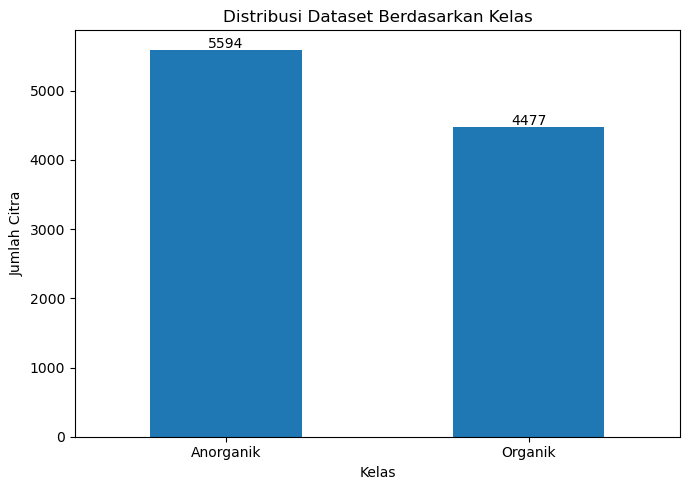

Grafik disimpan di: C:\Users\Asus\Klasifikasi_Sampah_KNN\Output\visualisasi\distribusi_kelas.png


In [15]:
import matplotlib.pyplot as plt

distribusi_kelas = df_bersih.groupby("Kelas")["Jumlah"].sum()

plt.figure(figsize=(7, 5))
distribusi_kelas.plot(kind="bar")

plt.title("Distribusi Dataset Berdasarkan Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Citra")
plt.xticks(rotation=0)

for i, jumlah in enumerate(distribusi_kelas.values):
    plt.text(i, jumlah + 30, str(jumlah), ha="center")

plt.tight_layout()

output_grafik = PROJECT_DIR / "Output" / "visualisasi" / "distribusi_kelas.png"
plt.savefig(output_grafik, dpi=300, bbox_inches="tight")

plt.show()

print("Grafik disimpan di:", output_grafik)

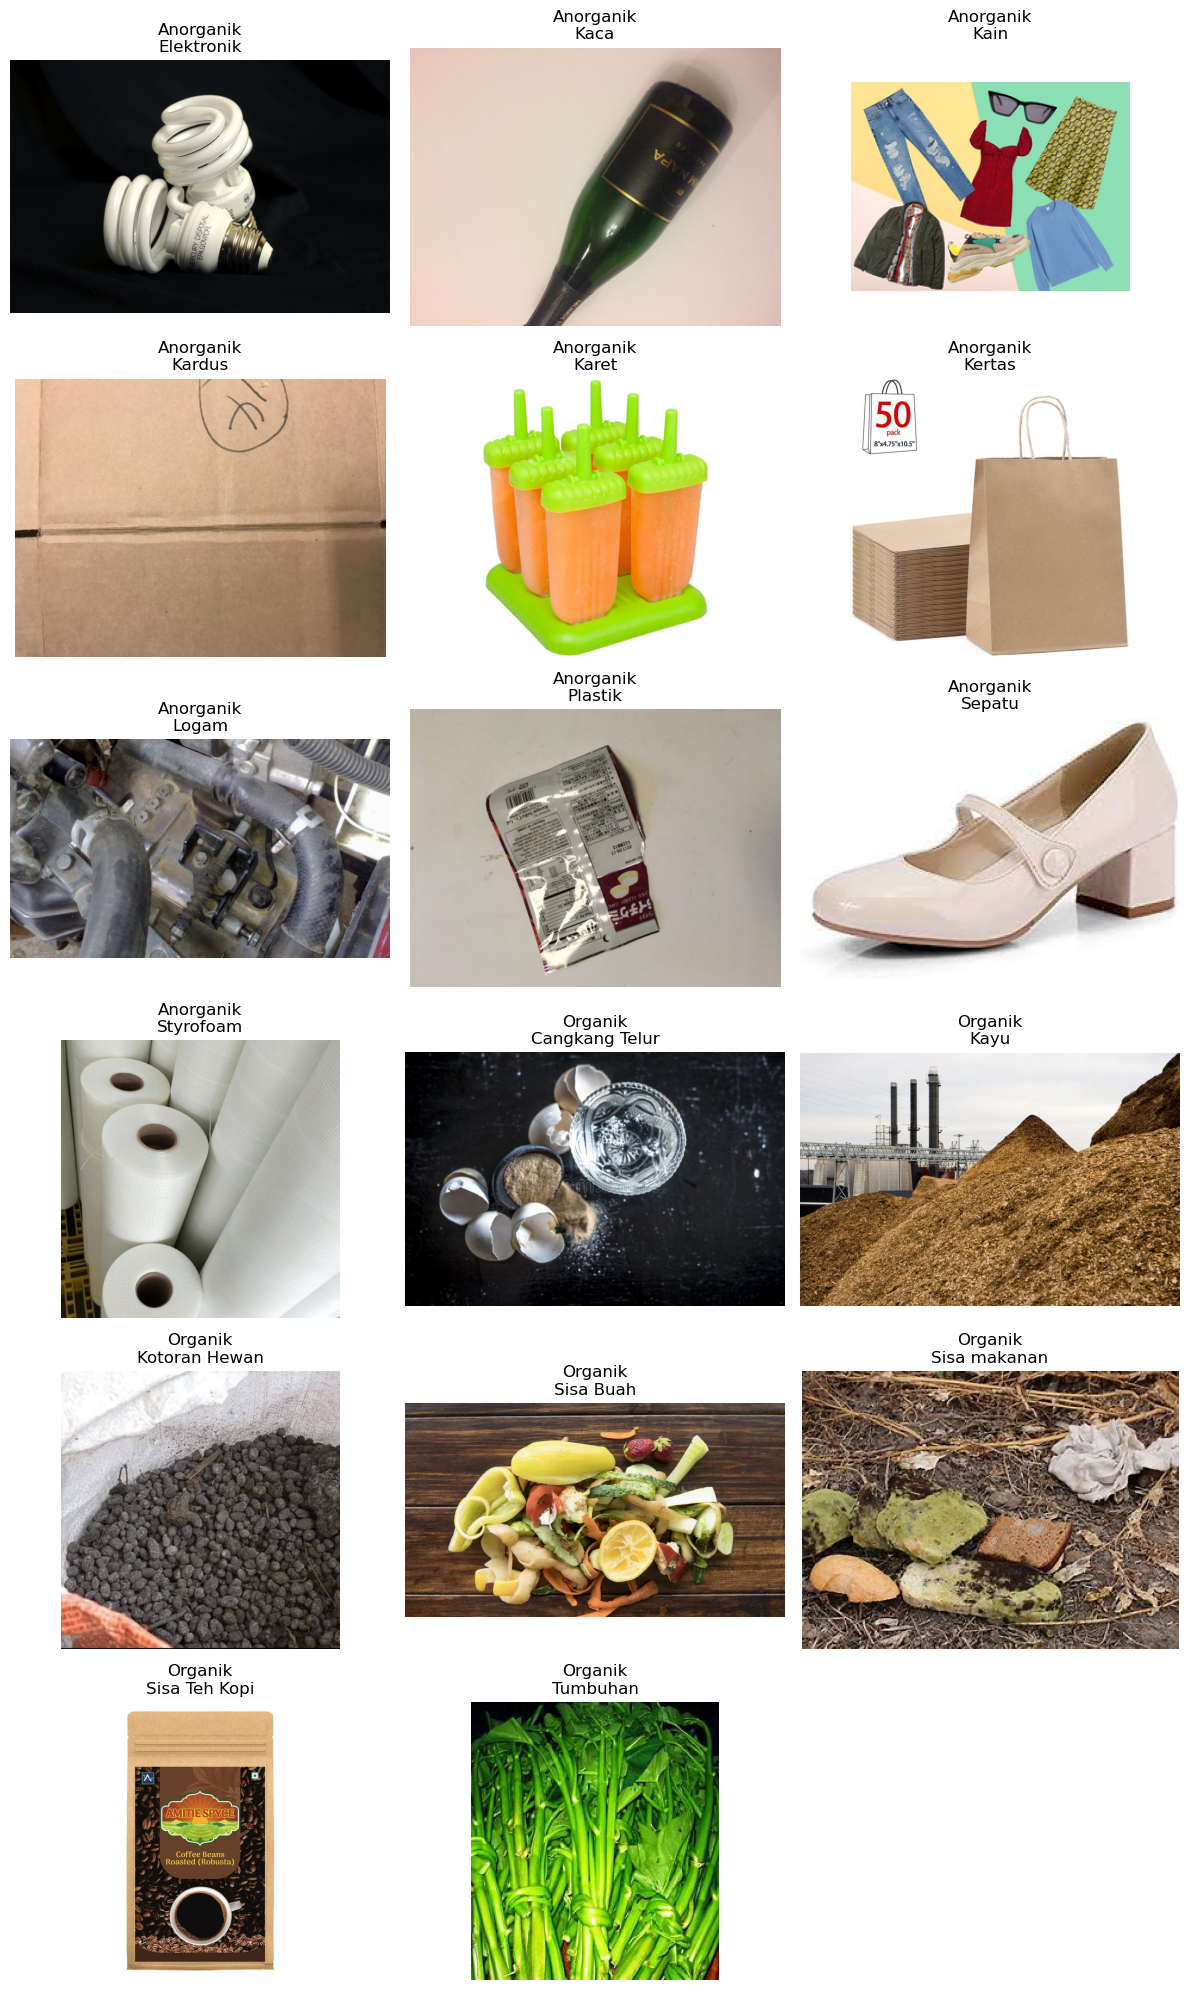

Gambar disimpan di: C:\Users\Asus\Klasifikasi_Sampah_KNN\Output\visualisasi\contoh_citra_dataset.png


In [17]:
import matplotlib.pyplot as plt
from PIL import Image

# Pastikan folder output tersedia
OUTPUT_VIS_DIR = PROJECT_DIR / "Output" / "visualisasi"
OUTPUT_VIS_DIR.mkdir(parents=True, exist_ok=True)

contoh_data = []

for kelas_dir in sorted(DATASET_BERSIH_DIR.iterdir()):
    if kelas_dir.is_dir():
        for sub_dir in sorted(kelas_dir.iterdir()):
            if sub_dir.is_dir():
                files = [f for f in sub_dir.iterdir() if f.is_file()]
                if files:
                    contoh_data.append(
                        (kelas_dir.name, sub_dir.name, files[0])
                    )

fig, axes = plt.subplots(6, 3, figsize=(12, 20))
axes = axes.flatten()

for i, (kelas, subkategori, file_path) in enumerate(contoh_data):
    img = Image.open(file_path).convert("RGB")

    axes[i].imshow(img)
    axes[i].set_title(f"{kelas}\n{subkategori}")
    axes[i].axis("off")

for j in range(len(contoh_data), len(axes)):
    axes[j].axis("off")

plt.tight_layout()

output_contoh = OUTPUT_VIS_DIR / "contoh_citra_dataset.png"
plt.savefig(output_contoh, dpi=300, bbox_inches="tight")

plt.show()

print("Gambar disimpan di:", output_contoh)

In [18]:
print("Jumlah contoh citra:", len(contoh_data))

for i, (kelas, subkategori, _) in enumerate(contoh_data, 1):
    print(f"{i}. {kelas} - {subkategori}")

Jumlah contoh citra: 17
1. Anorganik - Elektronik
2. Anorganik - Kaca
3. Anorganik - Kain
4. Anorganik - Kardus
5. Anorganik - Karet
6. Anorganik - Kertas
7. Anorganik - Logam
8. Anorganik - Plastik
9. Anorganik - Sepatu
10. Anorganik - Styrofoam
11. Organik - Cangkang Telur
12. Organik - Kayu
13. Organik - Kotoran Hewan
14. Organik - Sisa Buah
15. Organik - Sisa makanan
16. Organik - Sisa Teh Kopi
17. Organik - Tumbuhan


File               : -1x-1.jpg
Ukuran citra asli  : (2000, 1332)
Ukuran setelah resize: (224, 224)
Mode warna         : RGB


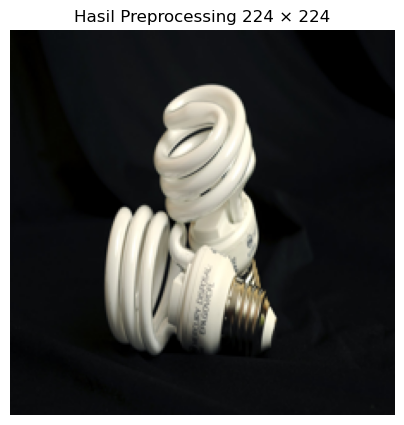

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

UKURAN_CITRA = (224, 224)

# Ambil 1 citra dari dataset bersih
contoh_file = valid_files[0]

# Sesuaikan path ke Dataset-Bersih
relative_path = contoh_file.relative_to(DATASET_DIR)
contoh_file_bersih = DATASET_BERSIH_DIR / relative_path

# Baca citra
img_asli = Image.open(contoh_file_bersih).convert("RGB")

# Resize
img_resize = img_asli.resize(UKURAN_CITRA)

print("File               :", contoh_file_bersih.name)
print("Ukuran citra asli  :", img_asli.size)
print("Ukuran setelah resize:", img_resize.size)
print("Mode warna         :", img_resize.mode)

plt.figure(figsize=(5, 5))
plt.imshow(img_resize)
plt.title("Hasil Preprocessing 224 × 224")
plt.axis("off")
plt.show()

In [20]:
from PIL import Image
from pathlib import Path

DATASET_PREPROCESSED_DIR = PROJECT_DIR / "Dataset" / "Dataset-Preprocessed"
DATASET_PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)

UKURAN_CITRA = (224, 224)

jumlah_berhasil = 0
jumlah_gagal = 0
file_gagal = []

for kelas_dir in sorted(DATASET_BERSIH_DIR.iterdir()):
    if kelas_dir.is_dir():

        for sub_dir in sorted(kelas_dir.iterdir()):
            if sub_dir.is_dir():

                output_subdir = (
                    DATASET_PREPROCESSED_DIR
                    / kelas_dir.name
                    / sub_dir.name
                )
                output_subdir.mkdir(parents=True, exist_ok=True)

                for file_path in sub_dir.iterdir():
                    if file_path.is_file():
                        try:
                            with Image.open(file_path) as img:
                                img = img.convert("RGB")
                                img = img.resize(UKURAN_CITRA)

                                output_file = output_subdir / (
                                    file_path.stem + ".jpg"
                                )

                                img.save(
                                    output_file,
                                    format="JPEG",
                                    quality=95
                                )

                            jumlah_berhasil += 1

                        except Exception as e:
                            jumlah_gagal += 1
                            file_gagal.append(
                                (file_path, str(e))
                            )

print("Jumlah berhasil :", jumlah_berhasil)
print("Jumlah gagal    :", jumlah_gagal)

if file_gagal:
    print("\nFile yang gagal:")
    for file_path, error in file_gagal[:20]:
        print("-", file_path, "->", error)

C:\Users\Asus\.conda\envs\Kuliah\Lib\site-packages\PIL\Image.py:1000: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Jumlah berhasil : 10071
Jumlah gagal    : 0


In [21]:
import cv2
import numpy as np
from pathlib import Path

# Ambil 1 citra hasil preprocessing
contoh_hist = next(DATASET_PREPROCESSED_DIR.rglob("*.jpg"))

img = cv2.imread(str(contoh_hist))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fitur_hist = []

for channel in range(3):
    hist = cv2.calcHist(
        [img_rgb],
        [channel],
        None,
        [256],
        [0, 256]
    )

    hist = cv2.normalize(hist, hist).flatten()
    fitur_hist.extend(hist)

fitur_hist = np.array(fitur_hist)

print("File                 :", contoh_hist.name)
print("Jumlah channel       : 3")
print("Bin per channel      : 256")
print("Panjang fitur        :", len(fitur_hist))
print("Ada NaN              :", np.isnan(fitur_hist).any())
print("Ada Inf              :", np.isinf(fitur_hist).any())

File                 : -1x-1.jpg
Jumlah channel       : 3
Bin per channel      : 256
Panjang fitur        : 768
Ada NaN              : False
Ada Inf              : False


In [22]:
import cv2
import numpy as np
import pandas as pd

OUTPUT_FITUR_DIR = PROJECT_DIR / "Output" / "fitur"
OUTPUT_FITUR_DIR.mkdir(parents=True, exist_ok=True)

data_histogram = []
gagal_histogram = []

for file_path in DATASET_PREPROCESSED_DIR.rglob("*.jpg"):
    try:
        relatif = file_path.relative_to(DATASET_PREPROCESSED_DIR)

        kelas = relatif.parts[0]
        subkategori = relatif.parts[1]
        nama_file = file_path.name

        img = cv2.imread(str(file_path))

        if img is None:
            raise ValueError("Gambar gagal dibaca oleh OpenCV")

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        fitur = []

        for channel in range(3):
            hist = cv2.calcHist(
                [img_rgb],
                [channel],
                None,
                [256],
                [0, 256]
            )

            hist = cv2.normalize(hist, hist).flatten()
            fitur.extend(hist)

        row = {
            "Kategori": kelas,
            "Subkategori": subkategori,
            "Nama_File": nama_file
        }

        for i, nilai in enumerate(fitur):
            row[f"Hist_{i}"] = nilai

        data_histogram.append(row)

    except Exception as e:
        gagal_histogram.append((file_path, str(e)))

df_histogram = pd.DataFrame(data_histogram)

output_csv_hist = OUTPUT_FITUR_DIR / "fitur_color_histogram.csv"
df_histogram.to_csv(output_csv_hist, index=False)

print("Jumlah data berhasil :", len(df_histogram))
print("Jumlah data gagal    :", len(gagal_histogram))
print("Jumlah kolom         :", df_histogram.shape[1])
print("Jumlah fitur warna   :", df_histogram.shape[1] - 3)
print("Ada NaN              :", df_histogram.isna().any().any())

print("\nFile disimpan di:")
print(output_csv_hist)

Jumlah data berhasil : 9697
Jumlah data gagal    : 330
Jumlah kolom         : 771
Jumlah fitur warna   : 768
Ada NaN              : False

File disimpan di:
C:\Users\Asus\Klasifikasi_Sampah_KNN\Output\fitur\fitur_color_histogram.csv


In [23]:
from collections import Counter

# Hitung semua file di Dataset-Preprocessed
semua_file_preprocessed = [
    f for f in DATASET_PREPROCESSED_DIR.rglob("*")
    if f.is_file()
]

print("Total seluruh file preprocessed :", len(semua_file_preprocessed))

# Distribusi ekstensi
ext_counter = Counter(f.suffix.lower() for f in semua_file_preprocessed)

print("\nDistribusi ekstensi:")
for ext, jumlah in sorted(ext_counter.items()):
    print(ext if ext else "[tanpa ekstensi]", ":", jumlah)

print("\nJumlah *.jpg yang terbaca rglob :", len(list(DATASET_PREPROCESSED_DIR.rglob("*.jpg"))))
print("Jumlah gagal histogram          :", len(gagal_histogram))

if gagal_histogram:
    print("\n20 contoh file gagal:")
    for file_path, error in gagal_histogram[:20]:
        print("-", file_path)
        print("  Error:", error)

Total seluruh file preprocessed : 10027

Distribusi ekstensi:
.jpg : 10027

Jumlah *.jpg yang terbaca rglob : 10027
Jumlah gagal histogram          : 330

20 contoh file gagal:
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Preprocessed\Anorganik\Karet\$10 ix ice pop molds made of durable BPA-free….jpg
  Error: Gambar gagal dibaca oleh OpenCV
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Preprocessed\Anorganik\Karet\1 par Luva doméstica de cor aleatória padrão margarida, luvas de borracha de manga comprida, luvas reutilizáveis para lavar louça, luvas de limpeza para forno de cozinha.jpg
  Error: Gambar gagal dibaca oleh OpenCV
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Preprocessed\Anorganik\Karet\100pcs Toddler Girls Minimalist Hair Tie _ SHEIN….jpg
  Error: Gambar gagal dibaca oleh OpenCV
- C:\Users\Asus\Klasifikasi_Sampah_KNN\Dataset\Dataset-Preprocessed\Anorganik\Karet\1mm 2mm 3mm 4mm 5mm High Temperature Non Toxic Red….jpg
  Error: Gambar gagal dibaca 

In [24]:
import shutil
import pandas as pd
from PIL import Image

# Hapus hasil preprocessing lama
if DATASET_PREPROCESSED_DIR.exists():
    shutil.rmtree(DATASET_PREPROCESSED_DIR)

DATASET_PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)

UKURAN_CITRA = (224, 224)

manifest = []
jumlah_berhasil = 0
jumlah_gagal = 0
file_gagal = []

id_gambar = 1

for kelas_dir in sorted(DATASET_BERSIH_DIR.iterdir()):
    if kelas_dir.is_dir():

        for sub_dir in sorted(kelas_dir.iterdir()):
            if sub_dir.is_dir():

                output_subdir = (
                    DATASET_PREPROCESSED_DIR
                    / kelas_dir.name
                    / sub_dir.name
                )
                output_subdir.mkdir(parents=True, exist_ok=True)

                for file_path in sorted(sub_dir.iterdir()):
                    if file_path.is_file():

                        try:
                            with Image.open(file_path) as img:
                                img = img.convert("RGB")
                                img = img.resize(UKURAN_CITRA)

                                nama_baru = f"img_{id_gambar:05d}.jpg"
                                output_file = output_subdir / nama_baru

                                img.save(
                                    output_file,
                                    format="JPEG",
                                    quality=95
                                )

                            manifest.append({
                                "Kategori": kelas_dir.name,
                                "Subkategori": sub_dir.name,
                                "Nama_File_Asli": file_path.name,
                                "Nama_File_Proses": nama_baru
                            })

                            jumlah_berhasil += 1
                            id_gambar += 1

                        except Exception as e:
                            jumlah_gagal += 1
                            file_gagal.append((file_path, str(e)))

# Simpan manifest
OUTPUT_FITUR_DIR = PROJECT_DIR / "Output" / "fitur"
OUTPUT_FITUR_DIR.mkdir(parents=True, exist_ok=True)

df_manifest = pd.DataFrame(manifest)

manifest_path = OUTPUT_FITUR_DIR / "manifest_dataset.csv"
df_manifest.to_csv(manifest_path, index=False)

print("Jumlah berhasil :", jumlah_berhasil)
print("Jumlah gagal    :", jumlah_gagal)
print("Jumlah manifest :", len(df_manifest))
print("Manifest        :", manifest_path)

C:\Users\Asus\.conda\envs\Kuliah\Lib\site-packages\PIL\Image.py:1000: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Jumlah berhasil : 10071
Jumlah gagal    : 0
Jumlah manifest : 10071
Manifest        : C:\Users\Asus\Klasifikasi_Sampah_KNN\Output\fitur\manifest_dataset.csv


In [25]:
import cv2
import numpy as np
import pandas as pd

data_histogram = []
gagal_histogram = []

for file_path in sorted(DATASET_PREPROCESSED_DIR.rglob("*.jpg")):
    try:
        relatif = file_path.relative_to(DATASET_PREPROCESSED_DIR)

        kelas = relatif.parts[0]
        subkategori = relatif.parts[1]
        nama_file = file_path.name

        img = cv2.imread(str(file_path))

        if img is None:
            raise ValueError("Gambar gagal dibaca oleh OpenCV")

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        fitur = []

        for channel in range(3):
            hist = cv2.calcHist(
                [img_rgb],
                [channel],
                None,
                [256],
                [0, 256]
            )

            hist = cv2.normalize(hist, hist).flatten()
            fitur.extend(hist)

        row = {
            "Kategori": kelas,
            "Subkategori": subkategori,
            "Nama_File": nama_file
        }

        for i, nilai in enumerate(fitur):
            row[f"Hist_{i}"] = nilai

        data_histogram.append(row)

    except Exception as e:
        gagal_histogram.append((file_path, str(e)))

df_histogram = pd.DataFrame(data_histogram)

output_csv_hist = OUTPUT_FITUR_DIR / "fitur_color_histogram.csv"
df_histogram.to_csv(output_csv_hist, index=False)

print("Jumlah data berhasil :", len(df_histogram))
print("Jumlah data gagal    :", len(gagal_histogram))
print("Jumlah kolom         :", df_histogram.shape[1])
print("Jumlah fitur warna   :", df_histogram.shape[1] - 3)
print("Ada NaN              :", df_histogram.isna().any().any())
print("Ada Inf              :", np.isinf(
    df_histogram.drop(columns=["Kategori", "Subkategori", "Nama_File"]).to_numpy()
).any())

print("\nFile disimpan di:")
print(output_csv_hist)

Jumlah data berhasil : 10071
Jumlah data gagal    : 0
Jumlah kolom         : 771
Jumlah fitur warna   : 768
Ada NaN              : False
Ada Inf              : False

File disimpan di:
C:\Users\Asus\Klasifikasi_Sampah_KNN\Output\fitur\fitur_color_histogram.csv


In [26]:
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops

contoh_glcm = next(DATASET_PREPROCESSED_DIR.rglob("*.jpg"))

img = cv2.imread(str(contoh_glcm))

if img is None:
    raise ValueError("Gambar gagal dibaca")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

glcm = graycomatrix(
    gray,
    distances=[1],
    angles=[0],
    levels=256,
    symmetric=True,
    normed=True
)

contrast = graycoprops(glcm, "contrast")[0, 0]
correlation = graycoprops(glcm, "correlation")[0, 0]
energy = graycoprops(glcm, "energy")[0, 0]
homogeneity = graycoprops(glcm, "homogeneity")[0, 0]

print("File        :", contoh_glcm.name)
print("Contrast    :", contrast)
print("Correlation :", correlation)
print("Energy      :", energy)
print("Homogeneity :", homogeneity)

hasil_glcm = np.array([
    contrast,
    correlation,
    energy,
    homogeneity
])

print("Jumlah fitur:", len(hasil_glcm))
print("Ada NaN     :", np.isnan(hasil_glcm).any())
print("Ada Inf     :", np.isinf(hasil_glcm).any())

File        : img_00001.jpg
Contrast    : 246.38002482383087
Correlation : 0.9765985432848142
Energy      : 0.15923696977653756
Homogeneity : 0.6412548947875636
Jumlah fitur: 4
Ada NaN     : False
Ada Inf     : False


In [27]:
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops

data_glcm = []
gagal_glcm = []

for file_path in sorted(DATASET_PREPROCESSED_DIR.rglob("*.jpg")):
    try:
        relatif = file_path.relative_to(DATASET_PREPROCESSED_DIR)

        kelas = relatif.parts[0]
        subkategori = relatif.parts[1]
        nama_file = file_path.name

        img = cv2.imread(str(file_path))

        if img is None:
            raise ValueError("Gambar gagal dibaca oleh OpenCV")

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        glcm = graycomatrix(
            gray,
            distances=[1],
            angles=[0],
            levels=256,
            symmetric=True,
            normed=True
        )

        contrast = graycoprops(glcm, "contrast")[0, 0]
        correlation = graycoprops(glcm, "correlation")[0, 0]
        energy = graycoprops(glcm, "energy")[0, 0]
        homogeneity = graycoprops(glcm, "homogeneity")[0, 0]

        data_glcm.append({
            "Kategori": kelas,
            "Subkategori": subkategori,
            "Nama_File": nama_file,
            "Contrast": contrast,
            "Correlation": correlation,
            "Energy": energy,
            "Homogeneity": homogeneity
        })

    except Exception as e:
        gagal_glcm.append((file_path, str(e)))

df_glcm = pd.DataFrame(data_glcm)

output_csv_glcm = OUTPUT_FITUR_DIR / "fitur_glcm.csv"
df_glcm.to_csv(output_csv_glcm, index=False)

fitur_glcm_array = df_glcm[
    ["Contrast", "Correlation", "Energy", "Homogeneity"]
].to_numpy()

print("Jumlah data berhasil :", len(df_glcm))
print("Jumlah data gagal    :", len(gagal_glcm))
print("Jumlah kolom         :", df_glcm.shape[1])
print("Jumlah fitur GLCM    :", 4)
print("Ada NaN              :", df_glcm.isna().any().any())
print("Ada Inf              :", np.isinf(fitur_glcm_array).any())

print("\nFile disimpan di:")
print(output_csv_glcm)

Jumlah data berhasil : 10071
Jumlah data gagal    : 0
Jumlah kolom         : 7
Jumlah fitur GLCM    : 4
Ada NaN              : False
Ada Inf              : False

File disimpan di:
C:\Users\Asus\Klasifikasi_Sampah_KNN\Output\fitur\fitur_glcm.csv


In [28]:
import pandas as pd
import numpy as np

# Gabungkan berdasarkan identitas file
df_fitur_final = pd.merge(
    df_histogram,
    df_glcm,
    on=["Kategori", "Subkategori", "Nama_File"],
    how="inner"
)

output_fitur_final = OUTPUT_FITUR_DIR / "fitur_final.csv"
df_fitur_final.to_csv(output_fitur_final, index=False)

kolom_identitas = ["Kategori", "Subkategori", "Nama_File"]
kolom_fitur = [c for c in df_fitur_final.columns if c not in kolom_identitas]

print("Jumlah baris          :", df_fitur_final.shape[0])
print("Jumlah kolom          :", df_fitur_final.shape[1])
print("Jumlah fitur total    :", len(kolom_fitur))
print("Ada NaN               :", df_fitur_final.isna().any().any())
print("Ada Inf               :", np.isinf(df_fitur_final[kolom_fitur].to_numpy()).any())

print("\nDistribusi kelas:")
print(df_fitur_final["Kategori"].value_counts())

print("\nFile disimpan di:")
print(output_fitur_final)

Jumlah baris          : 10071
Jumlah kolom          : 775
Jumlah fitur total    : 772
Ada NaN               : False
Ada Inf               : False

Distribusi kelas:
Kategori
Anorganik    5594
Organik      4477
Name: count, dtype: int64

File disimpan di:
C:\Users\Asus\Klasifikasi_Sampah_KNN\Output\fitur\fitur_final.csv


In [29]:
from sklearn.model_selection import train_test_split

# Pisahkan fitur dan label
X = df_fitur_final[kolom_fitur].copy()
y = df_fitur_final["Kategori"].copy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Jumlah seluruh data :", len(X))
print("Data training       :", len(X_train))
print("Data testing        :", len(X_test))

print("\nDistribusi training:")
print(y_train.value_counts())

print("\nDistribusi testing:")
print(y_test.value_counts())

Jumlah seluruh data : 10071
Data training       : 8056
Data testing        : 2015

Distribusi training:
Kategori
Anorganik    4475
Organik      3581
Name: count, dtype: int64

Distribusi testing:
Kategori
Anorganik    1119
Organik       896
Name: count, dtype: int64


In [30]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

# Fit hanya pada data training
X_train_scaled = scaler.fit_transform(X_train)

# Test hanya ditransform menggunakan scaler training
X_test_scaled = scaler.transform(X_test)

print("Shape training :", X_train_scaled.shape)
print("Shape testing  :", X_test_scaled.shape)

print("NaN training   :", np.isnan(X_train_scaled).any())
print("Inf training   :", np.isinf(X_train_scaled).any())

print("NaN testing    :", np.isnan(X_test_scaled).any())
print("Inf testing    :", np.isinf(X_test_scaled).any())

Shape training : (8056, 772)
Shape testing  : (2015, 772)
NaN training   : False
Inf training   : False
NaN testing    : False
Inf testing    : False


In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

hasil_k = []

for k in range(1, 21):
    model_knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean",
        weights="uniform"
    )

    scores = cross_val_score(
        model_knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    hasil_k.append({
        "K": k,
        "Mean_Accuracy": scores.mean(),
        "Std_Accuracy": scores.std()
    })

df_hasil_k = pd.DataFrame(hasil_k)

print(df_hasil_k)

k_terbaik = int(
    df_hasil_k.loc[
        df_hasil_k["Mean_Accuracy"].idxmax(),
        "K"
    ]
)

akurasi_cv_terbaik = df_hasil_k["Mean_Accuracy"].max()

print("\nK terbaik:", k_terbaik)
print("Mean accuracy CV terbaik:", akurasi_cv_terbaik)

     K  Mean_Accuracy  Std_Accuracy
0    1       0.769489      0.005795
1    2       0.774453      0.008968
2    3       0.773957      0.004785
3    4       0.782026      0.003997
4    5       0.773585      0.003613
5    6       0.781778      0.003082
6    7       0.771474      0.007388
7    8       0.772840      0.002582
8    9       0.764895      0.008009
9   10       0.771971      0.007700
10  11       0.763778      0.010595
11  12       0.768122      0.011083
12  13       0.761916      0.010368
13  14       0.768743      0.009519
14  15       0.760303      0.008155
15  16       0.764523      0.010430
16  17       0.756702      0.006903
17  18       0.761419      0.008234
18  19       0.756951      0.007980
19  20       0.759805      0.010181

K terbaik: 4
Mean accuracy CV terbaik: 0.7820257134187572


In [32]:
from sklearn.neighbors import KNeighborsClassifier

model_knn_final = KNeighborsClassifier(
    n_neighbors=4,
    metric="euclidean",
    weights="uniform"
)

model_knn_final.fit(
    X_train_scaled,
    y_train
)

print("Model berhasil dilatih")
print("K       :", model_knn_final.n_neighbors)
print("Metric  :", model_knn_final.metric)
print("Weights :", model_knn_final.weights)


Model berhasil dilatih
K       : 4
Metric  : euclidean
Weights : uniform


In [33]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Prediksi data test
y_pred = model_knn_final.predict(X_test_scaled)

# Evaluasi
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Anorganik", "Organik"]
)

accuracy = accuracy_score(y_test, y_pred)

precision_macro = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall_macro = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro"
)

precision_weighted = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall_weighted = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1_weighted = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Confusion Matrix:")
print(cm)

print("\nAccuracy           :", accuracy)

print("\nMacro Average:")
print("Precision          :", precision_macro)
print("Recall             :", recall_macro)
print("F1-Score           :", f1_macro)

print("\nWeighted Average:")
print("Precision          :", precision_weighted)
print("Recall             :", recall_weighted)
print("F1-Score           :", f1_weighted)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=["Anorganik", "Organik"],
        digits=4
    )
)

Confusion Matrix:
[[898 221]
 [207 689]]

Accuracy           : 0.7875930521091812

Macro Average:
Precision          : 0.7849062702003878
Recall             : 0.7857377242116685
F1-Score           : 0.7852830692256826

Weighted Average:
Precision          : 0.7879788464345463
Recall             : 0.7875930521091812
F1-Score           : 0.7877477878047265

Classification Report:
              precision    recall  f1-score   support

   Anorganik     0.8127    0.8025    0.8076      1119
     Organik     0.7571    0.7690    0.7630       896

    accuracy                         0.7876      2015
   macro avg     0.7849    0.7857    0.7853      2015
weighted avg     0.7880    0.7876    0.7877      2015



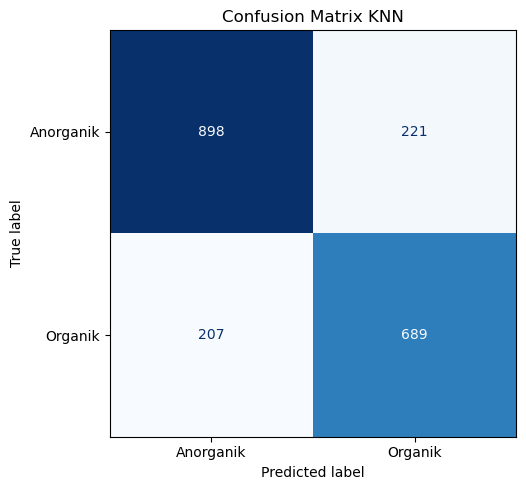

Confusion matrix disimpan di:
C:\Users\Asus\Klasifikasi_Sampah_KNN\Output\evaluasi\confusion_matrix_knn.png

Hasil evaluasi disimpan di:
C:\Users\Asus\Klasifikasi_Sampah_KNN\Output\evaluasi\hasil_evaluasi_knn.csv

Ringkasan evaluasi:
               Metrik     Nilai
0            Accuracy  0.787593
1     Macro Precision  0.784906
2        Macro Recall  0.785738
3      Macro F1-Score  0.785283
4  Weighted Precision  0.787979
5     Weighted Recall  0.787593
6   Weighted F1-Score  0.787748


In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd

OUTPUT_EVAL_DIR = PROJECT_DIR / "Output" / "evaluasi"
OUTPUT_EVAL_DIR.mkdir(parents=True, exist_ok=True)

# Visualisasi confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Anorganik", "Organik"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

plt.title("Confusion Matrix KNN")
plt.tight_layout()

output_cm = OUTPUT_EVAL_DIR / "confusion_matrix_knn.png"
plt.savefig(output_cm, dpi=300, bbox_inches="tight")
plt.show()

# Simpan ringkasan evaluasi
hasil_evaluasi = pd.DataFrame({
    "Metrik": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-Score"
    ],
    "Nilai": [
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted
    ]
})

output_eval_csv = OUTPUT_EVAL_DIR / "hasil_evaluasi_knn.csv"
hasil_evaluasi.to_csv(output_eval_csv, index=False)

print("Confusion matrix disimpan di:")
print(output_cm)

print("\nHasil evaluasi disimpan di:")
print(output_eval_csv)

print("\nRingkasan evaluasi:")
print(hasil_evaluasi)

In [35]:
import joblib

MODEL_DIR = PROJECT_DIR / "Model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "knn_model.pkl"
scaler_path = MODEL_DIR / "scaler.pkl"

joblib.dump(model_knn_final, model_path)
joblib.dump(scaler, scaler_path)

print("Model disimpan di:")
print(model_path)

print("\nScaler disimpan di:")
print(scaler_path)

print("\nModel tersedia :", model_path.exists())
print("Scaler tersedia:", scaler_path.exists())

Model disimpan di:
C:\Users\Asus\Klasifikasi_Sampah_KNN\Model\knn_model.pkl

Scaler disimpan di:
C:\Users\Asus\Klasifikasi_Sampah_KNN\Model\scaler.pkl

Model tersedia : True
Scaler tersedia: True


In [36]:
import cv2
import numpy as np
import joblib
from skimage.feature import graycomatrix, graycoprops

uji_path = PROJECT_DIR / "Uji" / "gambar_uji.jpg"

# Load model dan scaler
model_knn = joblib.load(MODEL_DIR / "knn_model.pkl")
scaler_loaded = joblib.load(MODEL_DIR / "scaler.pkl")

# Baca gambar
img = cv2.imread(str(uji_path))

if img is None:
    raise ValueError("Gambar uji gagal dibaca.")

# Resize
img = cv2.resize(img, (224, 224))

# ===== Color Histogram =====
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fitur_hist = []

for channel in range(3):
    hist = cv2.calcHist(
        [img_rgb],
        [channel],
        None,
        [256],
        [0, 256]
    )

    hist = cv2.normalize(hist, hist).flatten()
    fitur_hist.extend(hist)

# ===== GLCM =====
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

glcm = graycomatrix(
    gray,
    distances=[1],
    angles=[0],
    levels=256,
    symmetric=True,
    normed=True
)

fitur_glcm = [
    graycoprops(glcm, "contrast")[0, 0],
    graycoprops(glcm, "correlation")[0, 0],
    graycoprops(glcm, "energy")[0, 0],
    graycoprops(glcm, "homogeneity")[0, 0]
]

# Gabungkan fitur
fitur_final_uji = np.array(
    fitur_hist + fitur_glcm
).reshape(1, -1)

print("Jumlah fitur:", fitur_final_uji.shape[1])

# Scaling
fitur_scaled = scaler_loaded.transform(fitur_final_uji)

# Prediksi
hasil_prediksi = model_knn.predict(fitur_scaled)[0]

print("Hasil prediksi:", hasil_prediksi)

Jumlah fitur: 772
Hasil prediksi: Anorganik


C:\Users\Asus\.conda\envs\Kuliah\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [37]:
import json

config = {
    "image_size": [224, 224],
    "color_space": "RGB",
    "histogram": {
        "channels": 3,
        "bins_per_channel": 256,
        "total_features": 768,
        "normalized": True
    },
    "glcm": {
        "grayscale": True,
        "levels": 256,
        "distance": 1,
        "angle_degree": 0,
        "symmetric": True,
        "normed": True,
        "properties": [
            "contrast",
            "correlation",
            "energy",
            "homogeneity"
        ],
        "total_features": 4
    },
    "total_features": 772,
    "model": {
        "algorithm": "KNN",
        "n_neighbors": 4,
        "metric": "euclidean",
        "weights": "uniform"
    }
}

config_path = MODEL_DIR / "feature_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4)

print("Konfigurasi disimpan di:")
print(config_path)

print("\nFile tersedia:", config_path.exists())

Konfigurasi disimpan di:
C:\Users\Asus\Klasifikasi_Sampah_KNN\Model\feature_config.json

File tersedia: True


In [38]:
import numpy as np

# Cari 2 tetangga terdekat dari setiap data training.
# Tetangga pertama adalah data itu sendiri, jadi gunakan tetangga kedua.
distances_train, _ = model_knn_final.kneighbors(
    X_train_scaled,
    n_neighbors=2
)

nearest_distance_train = distances_train[:, 1]

# Threshold menggunakan percentile ke-95
distance_threshold = np.percentile(
    nearest_distance_train,
    95
)

print("Minimum distance :", nearest_distance_train.min())
print("Mean distance    :", nearest_distance_train.mean())
print("Maximum distance :", nearest_distance_train.max())
print("Threshold 95%    :", distance_threshold)

Minimum distance : 0.0
Mean distance    : 10.919874723195818
Maximum distance : 49.471057657871086
Threshold 95%    : 23.485351258428402


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Pisahkan data training menjadi sub-training dan calibration
X_subtrain, X_cal, y_subtrain, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Scaling hanya berdasarkan sub-training
scaler_cal = StandardScaler()

X_subtrain_scaled = scaler_cal.fit_transform(X_subtrain)
X_cal_scaled = scaler_cal.transform(X_cal)

# Model sementara untuk kalibrasi
knn_cal = KNeighborsClassifier(
    n_neighbors=4,
    metric="euclidean",
    weights="uniform"
)

knn_cal.fit(X_subtrain_scaled, y_subtrain)

# Prediksi data calibration
y_cal_pred = knn_cal.predict(X_cal_scaled)

# Ambil 4 tetangga terdekat
distances, indices = knn_cal.kneighbors(
    X_cal_scaled,
    n_neighbors=4
)

# Rata-rata jarak 4 tetangga
mean_distances = distances.mean(axis=1)

# Hitung rasio kesepakatan tetangga
train_labels = y_subtrain.reset_index(drop=True)

agreements = []

for idx_list in indices:
    labels = train_labels.iloc[idx_list]

    counts = labels.value_counts()
    agreement = counts.iloc[0] / 4

    agreements.append(agreement)

agreements = np.array(agreements)

# Hanya data calibration yang diprediksi benar
correct_mask = (
    y_cal.reset_index(drop=True).to_numpy()
    == y_cal_pred
)

correct_distances = mean_distances[correct_mask]
correct_agreements = agreements[correct_mask]

# Threshold jarak: percentile 95 dari prediksi yang benar
distance_threshold = np.percentile(
    correct_distances,
    95
)

print("Jumlah calibration       :", len(y_cal))
print("Prediksi benar           :", correct_mask.sum())

print("\nRata-rata jarak:")
print("Minimum                  :", correct_distances.min())
print("Mean                     :", correct_distances.mean())
print("Maximum                  :", correct_distances.max())
print("Threshold 95%            :", distance_threshold)

print("\nDistribusi agreement:")
unique, counts = np.unique(
    correct_agreements,
    return_counts=True
)

for u, c in zip(unique, counts):
    print(f"{u:.2f} : {c} data")

Jumlah calibration       : 1612
Prediksi benar           : 1257

Rata-rata jarak:
Minimum                  : 0.6829994424230708
Mean                     : 11.464796591924227
Maximum                  : 50.474271825891535
Threshold 95%            : 24.549424967867697

Distribusi agreement:
0.50 : 128 data
0.75 : 347 data
1.00 : 782 data


In [40]:
accepted_mask = (
    (mean_distances <= distance_threshold) &
    (agreements >= 0.75)
)

jumlah_diterima = accepted_mask.sum()
jumlah_ditolak = len(accepted_mask) - jumlah_diterima

akurasi_diterima = (
    y_cal.reset_index(drop=True).to_numpy()[accepted_mask]
    == y_cal_pred[accepted_mask]
).mean()

print("Total calibration :", len(y_cal))
print("Diterima          :", jumlah_diterima)
print("Ditolak           :", jumlah_ditolak)
print("Acceptance rate   :", jumlah_diterima / len(y_cal))
print("Accuracy accepted :", akurasi_diterima)

Total calibration : 1612
Diterima          : 1321
Ditolak           : 291
Acceptance rate   : 0.8194789081885856
Accuracy accepted : 0.8145344436033308


In [41]:
from sklearn.ensemble import IsolationForest
import joblib

novelty_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

novelty_model.fit(X_train_scaled)

# Uji pada data sampah test
novelty_pred_test = novelty_model.predict(X_test_scaled)

jumlah_dikenali = (novelty_pred_test == 1).sum()
jumlah_ditolak = (novelty_pred_test == -1).sum()

print("Data test sampah     :", len(X_test_scaled))
print("Dikenali sebagai data normal :", jumlah_dikenali)
print("Ditolak sebagai outlier      :", jumlah_ditolak)
print(
    "Persentase sampah diterima   :",
    jumlah_dikenali / len(X_test_scaled)
)

# Simpan model
novelty_path = MODEL_DIR / "novelty_model.pkl"
joblib.dump(novelty_model, novelty_path)

print("\nNovelty model disimpan di:")
print(novelty_path)

Data test sampah     : 2015
Dikenali sebagai data normal : 1997
Ditolak sebagai outlier      : 18
Persentase sampah diterima   : 0.9910669975186104

Novelty model disimpan di:
C:\Users\Asus\Klasifikasi_Sampah_KNN\Model\novelty_model.pkl


In [45]:
import cv2
import numpy as np
import pandas as pd
import joblib
from skimage.feature import graycomatrix, graycoprops

novelty_model = joblib.load(MODEL_DIR / "novelty_model.pkl")

def ekstraksi_fitur_uji(image_path):
    img = cv2.imread(str(image_path))

    if img is None:
        raise ValueError(f"Gambar gagal dibaca: {image_path}")

    img = cv2.resize(img, (224, 224))

    # Color Histogram
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fitur_hist = []

    for channel in range(3):
        hist = cv2.calcHist(
            [img_rgb],
            [channel],
            None,
            [256],
            [0, 256]
        )

        hist = cv2.normalize(hist, hist).flatten()
        fitur_hist.extend(hist)

    # GLCM
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    fitur_glcm = [
        graycoprops(glcm, "contrast")[0, 0],
        graycoprops(glcm, "correlation")[0, 0],
        graycoprops(glcm, "energy")[0, 0],
        graycoprops(glcm, "homogeneity")[0, 0]
    ]

    fitur = fitur_hist + fitur_glcm

    return pd.DataFrame(
        [fitur],
        columns=kolom_fitur
    )


daftar_uji = {
    "Sampah": PROJECT_DIR / "Uji" / "uji_sampah.jpg",
    "Bukan Sampah": PROJECT_DIR / "Uji" / "uji_bukan_sampah.jpg"
}

for nama, path in daftar_uji.items():

    fitur = ekstraksi_fitur_uji(path)

    fitur_scaled = scaler.transform(fitur)

    novelty_pred = novelty_model.predict(fitur_scaled)[0]
    novelty_score = novelty_model.decision_function(fitur_scaled)[0]

    print(f"\n{nama}")
    print("Novelty prediction :", novelty_pred)
    print("Novelty score      :", novelty_score)

    if novelty_pred == -1:
        print("Hasil              : TIDAK DIKENALI")
    else:
        prediksi_knn = model_knn_final.predict(fitur_scaled)[0]
        print("Hasil              :", prediksi_knn)


Sampah
Novelty prediction : 1
Novelty score      : 0.06662224717644516
Hasil              : Anorganik

Bukan Sampah
Novelty prediction : 1
Novelty score      : 0.08114976399880153
Hasil              : Organik


In [44]:
from pathlib import Path

uji_sampah = PROJECT_DIR / "Uji" / "uji_sampah.jpg"
uji_bukan_sampah = PROJECT_DIR / "Uji" / "uji_bukan_sampah.jpg"

print("uji_sampah ada       :", uji_sampah.exists())
print("uji_bukan_sampah ada :", uji_bukan_sampah.exists())

uji_sampah ada       : True
uji_bukan_sampah ada : True
